# ECG Arrhythmia Explorer

## Abstract

В данной работе проводится анализ электрокардиографических (ЭКГ) признаков на основе клинической базы данных PTB-XL. Исходный датасет объединяет две базы: PTB-XL (демографические данные и SCP-диагнозы) и PTB-XL+ (автоматически извлечённые числовые признаки ЭКГ), что позволяет анализировать связь между электрофизиологическими параметрами сердца и кардиологическими диагнозами. Основные направления исследования: дескриптивный анализ ключевых ЭКГ-параметров, сравнение методов коррекции QT-интервала, изучение электрофизиологического профиля фибрилляции предсердий

## Dataset Description

Данные получены из двух публичных источников PhysioNet:

- **PTB-XL** (v1.0.3) — 21 837 записей 12-отведенческих ЭКГ от 18 885 пациентов. Содержит демографические данные (возраст, пол), стратификационные метки и диагнозы в формате SCP-кодов с уровнями уверенности.
- **PTB-XL+** (v1.0.1) — расширение PTB-XL с автоматически извлечёнными числовыми признаками сигнала: ЧСС, интервалы, оси.

После объединения по `ecg_id` итоговый датасет содержит **21 799 записей** и **100 колонок**:

- **Демография:** `age`, `sex`
- **Временны́е интервалы:** `heart_rate`, `rr_mean`, `pr_interval`, `qrs_duration`, `qt_interval`
- **Коррекция QT:** `qtc_bazett`, `qtc_fridericia`, `qtc_framingham`
- **Электрические оси:** `p_axis`, `qrs_axis`, `t_axis`
- **P-волна:** `p_duration`, `p_found`
- **SCP-диагнозы:** ~70 бинарных колонок `scp_*`
- **Производные колонки:** `age_group`, `heart_rate_group`, `abnormal_flag`, `num_diagnoses`, `qtc_spread`, `axis_deviation`, `pr_missing`

## **Скачивание библиотеки wfdb для чтения медицинских показаний**

In [2]:
!pip install wfdb


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## **Импортирование нужных библиотек**

In [3]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import ast

## **Скачивание базы данных**

In [4]:
# !wget -r -N -c -np "https://physionet.org/files/ptb-xl/1.0.3/records100/"

In [5]:
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/12sl_features.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/features/feature_description.csv
# !wget -r -N -c -np https://physionet.org/files/ptb-xl-plus/1.0.1/labels/

## **Извлечение данных из баз данных**

In [6]:
ptb_xl = pd.read_csv("data/raw/ptb-xl/ptbxl_database.csv")
ptb_xlp = pd.read_csv("data/raw/ptb-xl+/features/12sl_features.csv")
scp_stat = pd.read_csv("data/raw/ptb-xl/scp_statements.csv")


# **Составление и очистка базы данных**

### Составление своей базы данных через merge двух нужных баз

In [7]:
selected_columns = ptb_xl[
    [
        "ecg_id",
        "patient_id",
        "age",
        "sex",
        "strat_fold",
        "filename_lr",
        "scp_codes"
    ]
]
selected_columns.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [8]:
selected_columns2 = ptb_xlp[
    [
    "ecg_id",
    "HR_Ventr_Global",
    "RR_Mean_Global",
    "QRS_Count_Global",
    "PR_Int_Global",
    "QRS_Dur_Global",
    "QT_Int_Global",
    "QT_IntCorr_Global",
    "QT_IntBazett_Global",
    "QT_IntFridericia_Global",
    "QT_IntFramingham_Global",
    "P_AxisFront_Global",
    "R_AxisFrontal_Global",
    "T_AxisFront_Global",
    "P_Dur_Global",
    "P_Found_Global"
]]
selected_columns2 = selected_columns2.rename(columns={
    "HR_Ventr_Global": "heart_rate", # сколько раз сердце бьётся за минуту
    "RR_Mean_Global": "rr_mean", # сколько в среднем милисекунд между ударами
    "QRS_Count_Global": "qrs_count", # PTB-XL — это обычно 10-секундные ЭКГ-записи. Поэтому qrs_count примерно показывает, сколько сердечных ударов было за эти 10 секунд
    "PR_Int_Global": "pr_interval", # показывает, насколько быстро электрический сигнал проходит от предсердий к желудочкам
    "QRS_Dur_Global": "qrs_duration", # QRS показывает, как быстро электрический сигнал распространяется по желудочкам
    "QT_Int_Global": "qt_interval", # это сколько времени желудочки “электрически заняты” одним ударом (активация желудочков + восстановление желудочков)
    "QT_IntCorr_Global": "qtc_corrected", # скорректированный QT-интервал
    "QT_IntBazett_Global": "qtc_bazett", # QTc, рассчитанный по формуле Bazett (QTc = QT / sqrt(RR)) Очень популярная формула, но она может давать перекосы при очень высокой или очень низкой частоте сердечных сокращений.
    "QT_IntFridericia_Global": "qtc_fridericia", # QTc, рассчитанный по формуле Fridericia (QTc = QT / RR^(1/3)) Fridericia часто ведёт себя мягче при изменении heart_rate.
    "QT_IntFramingham_Global": "qtc_framingham", # QTc, рассчитанный по формуле Framingham (QTc = QT + 0.154 × (1 - RR)) Bazett и Fridericia используют деление на степень RR, а Framingham использует более линейную поправку:
    "P_AxisFront_Global": "p_axis", # Электрическая ось P-волны во фронтальной плоскости в градусах. Ось показывает, в какую сторону в среднем направлена электрическая активность.
    "R_AxisFrontal_Global": "qrs_axis", # Электрическая ось желудочков.
    "T_AxisFront_Global": "t_axis", # Электрическая ось T-волны во фронтальной плоскости.
    "P_Dur_Global": "p_duration", # Длительность P-волны. То есть сколько времени длится электрическая активация предсердий.
    "P_Found_Global": "p_found" # Бинарный или категориальный технический признак: была ли найдена P-волна алгоритмом.
})

main = pd.read_csv("data/processed/ecg_research_dataset.csv")
merge = main.merge(selected_columns2, on="ecg_id", how="right")
merge.to_csv("data/processed/ecg_research_dataset.csv", index=False)

Чистим названия колонок (убираем появившиеся _x)

In [9]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
#data = data.drop(columns=["sex_y", "patient_id_y","age_y","sex_y","strat_fold_y","filename_lr_y","scp_codes_y"])
rename_columns = {i : i[:-2] for i in data.columns if i[-1] == "x" and i[-2] == "_"}
data = data.rename(columns=rename_columns)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)


Убираем айдишники

In [10]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data = data.drop(columns=data.columns[:2])
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

Выносим диагнозы в колонки и делаем флаг-столбец проверяющий наличие патологий в принципе

In [11]:
codes = data["scp_codes"].apply(ast.literal_eval)
scp_data = pd.json_normalize(codes).fillna(0)
scp_data = scp_data.add_prefix("scp_")
data = pd.concat([data, scp_data], axis=1)

def abnormal(x):
    active = [k for k, v in x.items() if v > 0]
    return 0 if active == ["NORM"] else 1

data['abnormal_flag'] = codes.apply(abnormal)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

Возрастная группа + количество SCP диагнозов

In [12]:
data["num_diagnoses"] = codes.apply(lambda x: sum(1 for v in x.values() if v > 0))
def ages(x):
    if x < 35: return "young"
    if x < 60: return "middle"
    return "senior"
data["age_group"] = data["age"].apply(ages)

### Нужно понять, как определить heart_rate_group. Для этого сначала построим визуализацию и разнесем в 3 группы: bradycardia, normal_hr, tachycardia

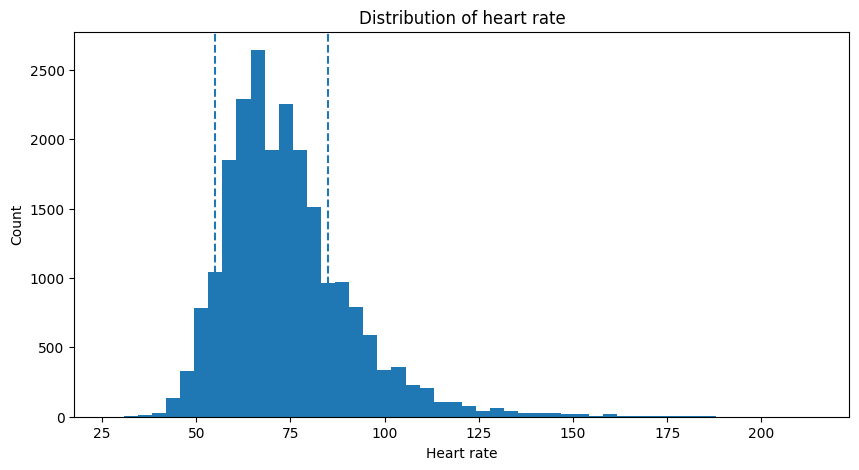

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(data["heart_rate"].dropna(), bins=50)
plt.xlabel("Heart rate")
plt.ylabel("Count")
plt.title("Distribution of heart rate")
plt.axvline(55, linestyle="--", label="HR = 60")
plt.axvline(85, linestyle="--", label="HR = 100")
plt.show()

Распределение сердцебиения на группы

In [14]:
def hrg(x):
    if x < 60: return "bradycardia"
    if x < 100: return "normal_hr"
    return "tachycardia"
data["heart_rate_group"] = data["heart_rate"].apply(hrg)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)

In [15]:
data = pd.read_csv("data/processed/ecg_research_dataset.csv")
data.groupby("heart_rate_group").describe()

age                                                \
                    count       mean        std   min   25%   50%   75%   
heart_rate_group                                                          
bradycardia        3662.0  58.948662  25.281169  11.0  48.0  60.0  69.0   
normal_hr         16497.0  62.632054  32.049567   3.0  50.0  62.0  73.0   
tachycardia        1640.0  72.681098  44.564219   2.0  56.0  68.0  79.0   

                             sex            ... abnormal_flag       \
                    max    count      mean  ...           75%  max   
heart_rate_group                            ...                      
bradycardia       300.0   3662.0  0.373839  ...           1.0  1.0   
normal_hr         300.0  16497.0  0.498394  ...           1.0  1.0   
tachycardia       300.0   1640.0  0.520732  ...           1.0  1.0   

                 num_diagnoses                                               
                         count      mean       std  min  25%  50%  75%  max  
heart_rate_group                                                             
bradycardia             3662.0  1.369743  0.718767  0.0  1.0  1.0  2.0  5.0  
normal_hr              16497.0  1.460811  0.808797  0.0  1.0  1.0  2.0  5.0  
tachycardia             1640.0  1.768293  0.996624  1.0  1.0  1.0  2.0  5.0  

[3 rows x 728 columns]

Добавляем разницу между максимальным и минимальным QTc среди Bazett, Fridericia, Framingham
Добавляем разбиение нормальную, левую или правую девиацию электрической оси сердца по qrs_axis

In [16]:
data['qtc_spread'] = (
    data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham']].max(axis=1)
    - data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham']].min(axis=1)
)

def classify_axis(x):
    if pd.isna(x):
        return 'unknown'
    if -30 <= x <= 90:
        return 'normal'
    elif x < -30:
        return 'left_deviation'
    else:
        return 'right_deviation'
    
data["axis_deviation"] = data["qrs_axis"].apply(classify_axis)
data.to_csv("data/processed/ecg_research_dataset.csv", index=False)
print(data[['qtc_bazett', 'qtc_fridericia', 'qtc_framingham', 'qtc_spread']].describe())

print("\nDistribution axis_deviation:")
print(data['axis_deviation'].value_counts())

         qtc_bazett  qtc_fridericia  qtc_framingham    qtc_spread
count  21799.000000    21799.000000    21799.000000  21799.000000
mean     433.060874      419.879765      419.590027     19.274003
std       33.127046       29.032658       27.520224     17.483077
min      176.000000      160.000000      201.000000      0.000000
25%      412.000000      402.000000      403.000000      8.000000
50%      430.000000      417.000000      417.000000     15.000000
75%      450.000000      434.000000      433.000000     26.000000
max      841.000000      809.000000      694.000000    393.000000

Distribution axis_deviation:
axis_deviation
normal             18895
left_deviation      2437
right_deviation      466
unknown                1
Name: count, dtype: int64


В датасет добавлены следующие производные колонки:

| Колонка | Тип | Описание |
|---|---|---|
| `abnormal_flag` | int (0/1) | 1 = есть патологический диагноз |
| `num_diagnoses` | int | Число активных SCP-диагнозов |
| `age_group` | str | young / middle / senior |
| `heart_rate_group` | str | bradycardia / normal_hr / tachycardia |
| `pr_missing` | int (0/1) | 1 = PR-интервал не измерим (нет P-волны) |
| `qtc_spread` | float | Разброс между Bazett, Fridericia, Framingham (мс) |
| `axis_deviation` | str | normal / left_deviation / right_deviation |

### Data cleanup preparation

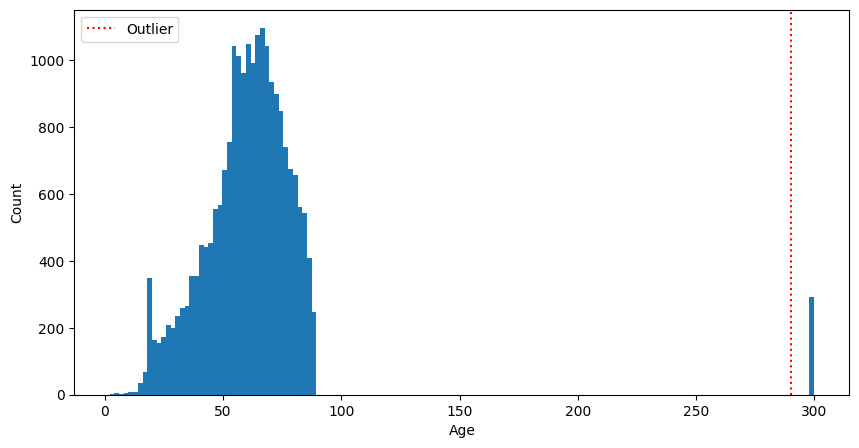

In [17]:
plt.figure(figsize=(10,5))
plt.hist(data["age"].dropna(), bins = 150)
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(290, color="red", label="Outlier", linestyle=":")
plt.legend()
plt.show()

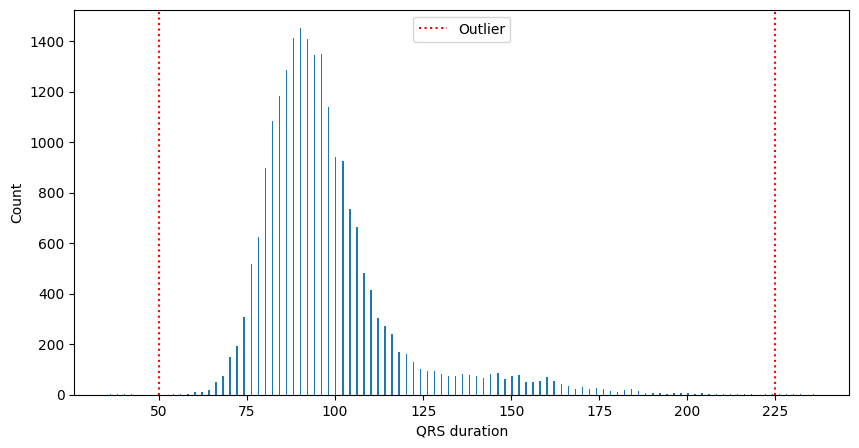

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(data["qrs_duration"].dropna(), bins = 500)
plt.xlabel("QRS duration")
plt.ylabel("Count")
plt.axvline(225, linestyle=":", color = "red", label="Outlier")
plt.axvline(50, linestyle=":", color = "red")
plt.legend()
plt.show()

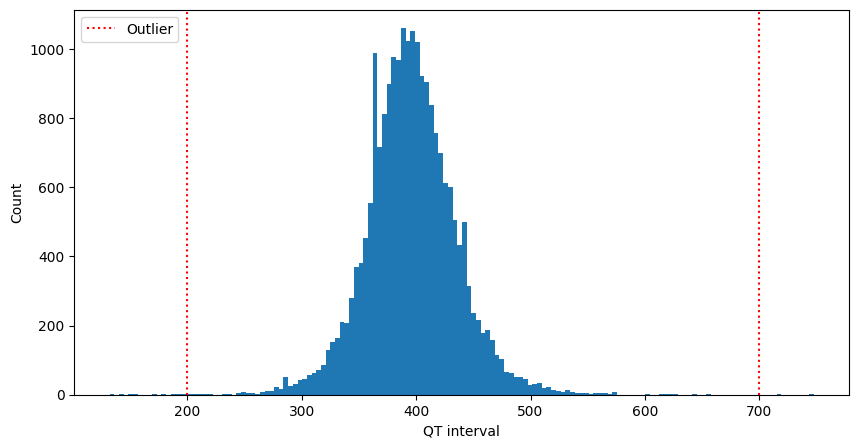

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(data["qt_interval"].dropna(), bins = 150)
plt.xlabel("QT interval")
plt.ylabel("Count")
plt.axvline(200, label="Outlier", linestyle=":", color="red")
plt.axvline(700, linestyle=":", color="red")
plt.legend()
plt.show()

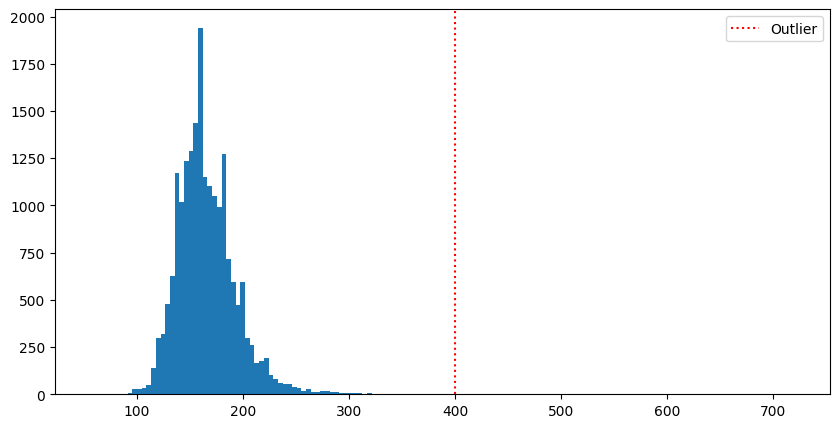

In [20]:
plt.figure(figsize=(10,5))
plt.hist(data["pr_interval"].dropna(), bins = 150)
plt.axvline(400, linestyle=":", color="red", label="Outlier")
plt.legend()
plt.show()

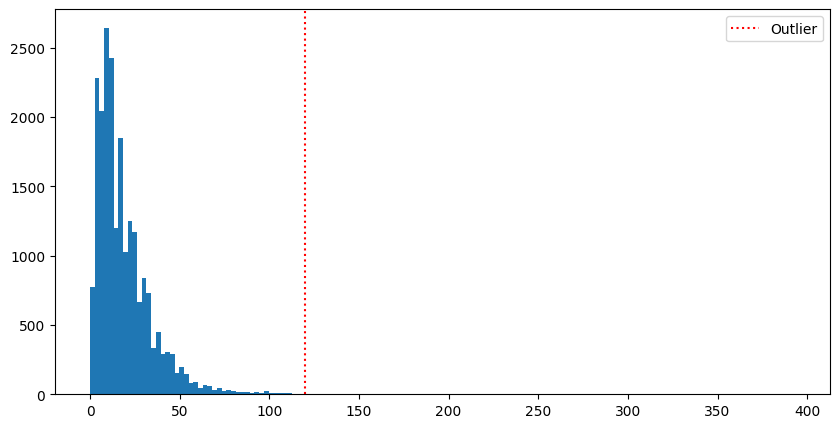

In [21]:
plt.figure(figsize=(10,5))
plt.hist(data["qtc_spread"].dropna(), bins = 150)
plt.axvline(120, linestyle=":", color="red", label="Outlier")
plt.legend()
plt.show()

In [22]:
for col in data.columns:
    sm = data[col].isna().sum()
    if sm > 0:
        print(f"{col}: {sm}")

pr_interval: 2013
p_axis: 1994
qrs_axis: 1
t_axis: 4
p_duration: 2032


### Data pre-cleanup

In [23]:
cdata = data.copy()
n0 = len(cdata)
cdata = cdata[cdata["age"] <= 120]
key_cols = ['heart_rate', 'rr_mean', 'qrs_duration', 'qt_interval',
            'qtc_bazett', 'qtc_fridericia', 'qtc_framingham', 'qrs_axis', 'age']
cdata = cdata.dropna(subset=key_cols)
cdata = cdata[
    cdata['heart_rate'].between(20, 300) &
    cdata['qrs_duration'].between(50, 225) &
    cdata['qt_interval'].between(200, 700) &
    cdata['rr_mean'].between(200, 3000)
]
cdata.to_csv("data/processed/cleaned_ecg_dataset.csv", index=False)
print(f"Deleted {n0 - len(cdata)} rows (from {n0} to {len(cdata)})")

Deleted 320 rows (from 21799 to 21479)


In [24]:
cdata = cdata.dropna(subset=["qrs_axis"])
cdata = cdata.dropna(subset=["t_axis"])
cdata['pr_missing'] = cdata['pr_interval'].isna().astype(int)
cdata["pr_interval"] = cdata["pr_interval"].fillna(0)


In [25]:
no_p = cdata['p_found'] == 0
no_pr = cdata['pr_interval'] == 0
print("Нет P-волны:", no_p.sum())
print("Нет PR:", no_pr.sum())  
print("Совпадают:", (no_p & no_pr).sum())

Нет P-волны: 1957
Нет PR: 1910
Совпадают: 1782


In [26]:
cdata = cdata[cdata["pr_interval"] <= 400]
cdata = cdata[cdata["qtc_spread"] <= 120]

## Descriptive Statistics

Считаем основные статистики для ключевых числовых полей: mean, median, std, min, max.
Используем `cdata` — очищенный датасет (21 479 записей).

In [27]:
numeric_cols = [
    'heart_rate', 'rr_mean', 'qrs_duration',
    'qt_interval', 'pr_interval', 'age',
    'qtc_bazett', 'qtc_fridericia', 'qtc_framingham', 'qtc_spread'
]
stats = cdata[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).round(5)
stats

,heart_rate,rr_mean,qrs_duration,qt_interval,pr_interval,age,qtc_bazett,qtc_fridericia,qtc_framingham,qtc_spread
mean,74.01125,847.04160,97.30650,395.78757,151.23974,59.49937,432.70960,419.72020,419.49708,18.73052
median,71.00000,842.00000,94.00000,394.00000,160.00000,61.00000,430.00000,417.00000,417.00000,14.00000
std,16.81008,173.73793,19.39306,38.48494,54.15248,16.76148,31.85131,27.73755,26.41693,15.36888
min,31.00000,300.00000,54.00000,210.00000,0.00000,2.00000,231.00000,224.00000,228.00000,0.00000
max,199.00000,1932.00000,224.00000,654.00000,398.00000,89.00000,697.00000,643.00000,618.00000,120.00000


In [28]:
print("=== heart_rate_group ===")
print(cdata['heart_rate_group'].value_counts())
print(f"\n=== age_group ===")
print(cdata['age_group'].value_counts())
print(f"\n=== sex (0=female, 1=male) ===")
print(cdata['sex'].value_counts())
print(f"\n=== axis_deviation ===")
print(cdata['axis_deviation'].value_counts())
print(f"\n=== abnormal_flag ===")
print(cdata['abnormal_flag'].value_counts())

=== heart_rate_group ===
heart_rate_group
normal_hr      16249
bradycardia     3629
tachycardia     1541
Name: count, dtype: int64

=== age_group ===
age_group
senior    11692
middle     7733
young      1994
Name: count, dtype: int64

=== sex (0=female, 1=male) ===
sex
0    11238
1    10181
Name: count, dtype: int64

=== axis_deviation ===
axis_deviation
normal             18638
left_deviation      2329
right_deviation      452
Name: count, dtype: int64

=== abnormal_flag ===
abnormal_flag
1    12474
0     8945
Name: count, dtype: int64


## Plots
Data Visualisation with dependencies

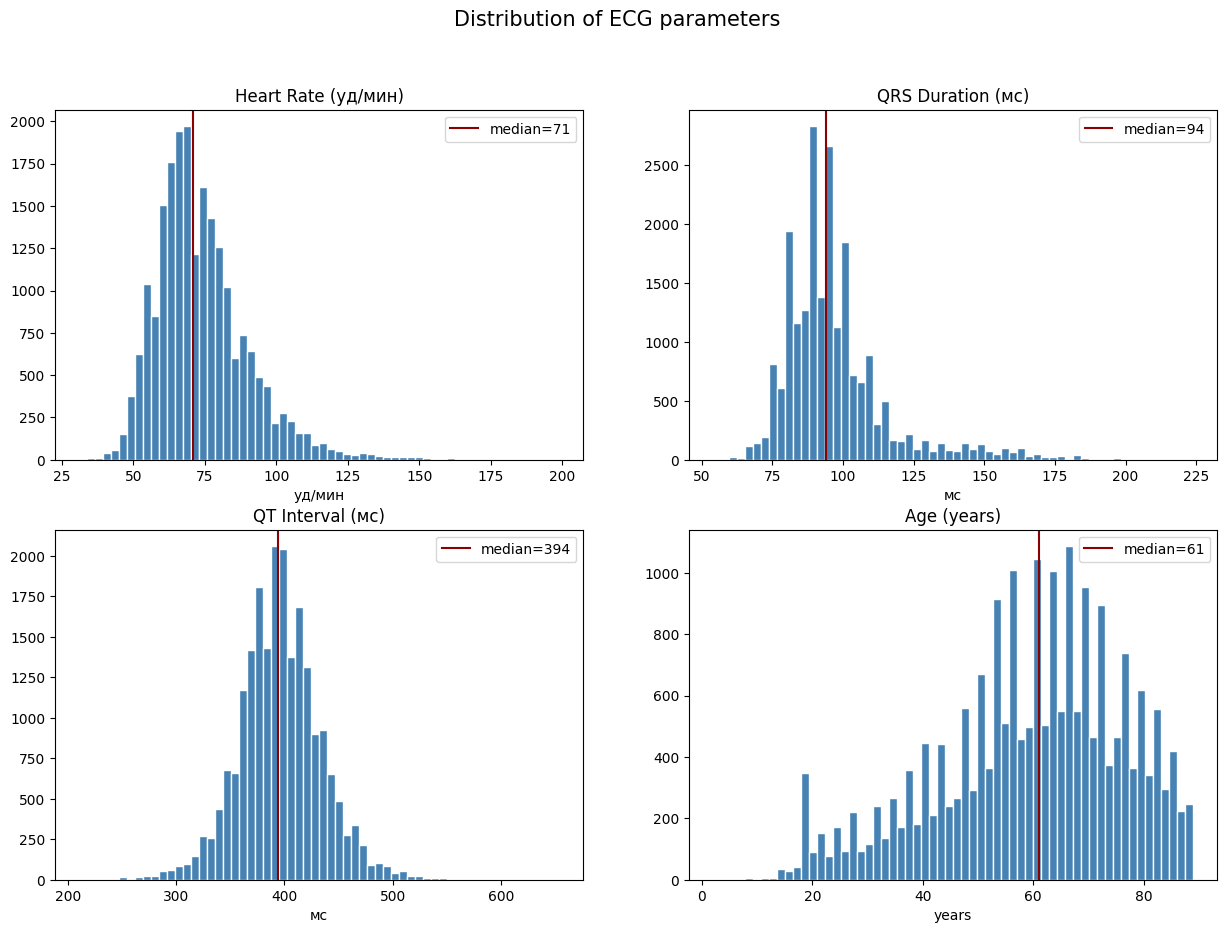

In [29]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
fig.suptitle("Distribution of ECG parameters", fontsize=15)
axes[0,0].hist(cdata["heart_rate"], bins=60, color="steelblue", edgecolor="white")
axes[0,0].axvline(cdata["heart_rate"].median(), linestyle="-",label=f"median={cdata['heart_rate'].median():.0f}", color="darkred")
axes[0,0].set_title("Heart Rate (уд/мин)")
axes[0,0].set_xlabel("уд/мин")
axes[0,0].legend()

axes[0,1].hist(cdata["qrs_duration"], bins=60, color="steelblue", edgecolor="white")
axes[0,1].axvline(cdata["qrs_duration"].median(), linestyle="-",label=f"median={cdata['qrs_duration'].median():.0f}", color="darkred")
axes[0,1].set_title("QRS Duration (мс)")
axes[0,1].set_xlabel("мс")
axes[0,1].legend()


axes[1,0].hist(cdata["qt_interval"], bins=60, color="steelblue", edgecolor="white")
axes[1,0].axvline(cdata["qt_interval"].median(), linestyle="-",label=f"median={cdata['qt_interval'].median():.0f}", color="darkred")
axes[1,0].set_title("QT Interval (мс)")
axes[1,0].set_xlabel("мс")
axes[1,0].legend()

axes[1,1].hist(cdata["age"], bins=60, color="steelblue", edgecolor="white")
axes[1,1].axvline(cdata["age"].median(), linestyle="-",label=f"median={cdata['age'].median():.0f}", color="darkred")
axes[1,1].set_title("Age (years)")
axes[1,1].set_xlabel("years")
axes[1,1].legend()

plt.show()

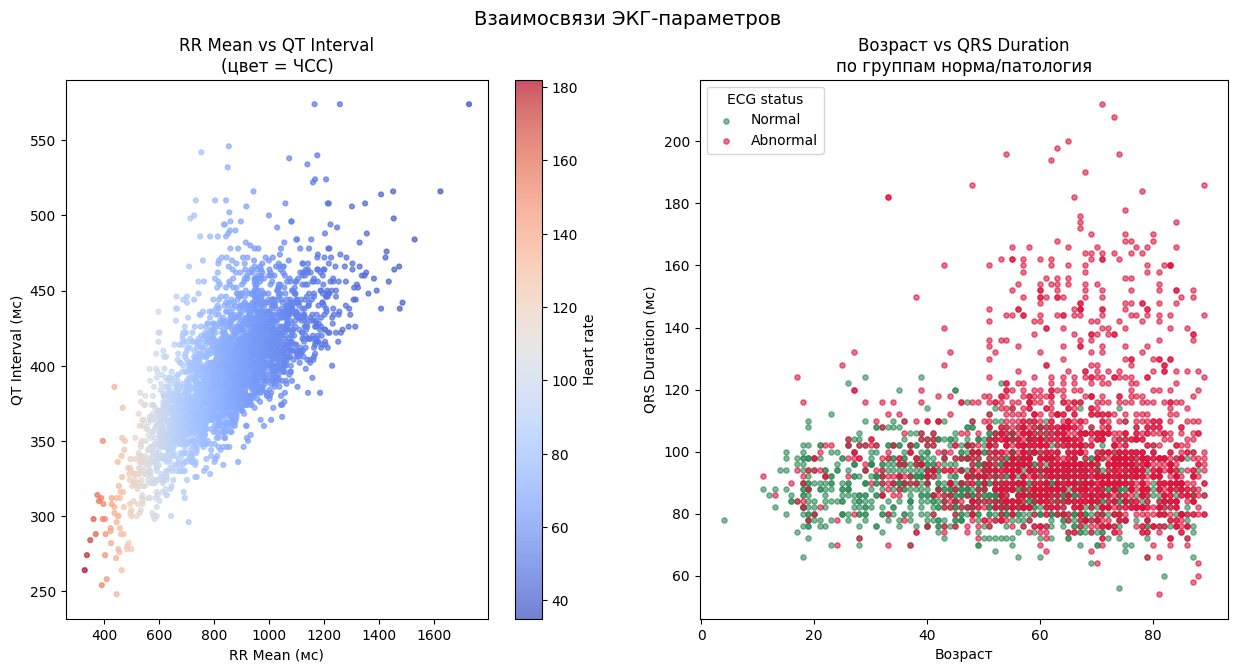

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Взаимосвязи ЭКГ-параметров', fontsize=14)

sample = cdata.sample(3000, random_state=42)

sc = axes[0].scatter(
    sample['rr_mean'],
    sample['qt_interval'],
    c=sample['heart_rate'],
    cmap='coolwarm',
    alpha=0.7,
    s=12
)

plt.colorbar(sc, ax=axes[0], label='Heart rate')
axes[0].set_xlabel('RR Mean (мс)')
axes[0].set_ylabel('QT Interval (мс)')
axes[0].set_title('RR Mean vs QT Interval')

normal = sample[sample['abnormal_flag'] == 0]
abnormal = sample[sample['abnormal_flag'] == 1]

axes[1].scatter(
    normal['age'],
    normal['qrs_duration'],
    color='seagreen',
    alpha=0.6,
    s=14,
    label='Normal'
)

axes[1].scatter(
    abnormal['age'],
    abnormal['qrs_duration'],
    color='crimson',
    alpha=0.6,
    s=14,
    label='Abnormal'
)

axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('QRS Duration (мс)')
axes[1].set_title('Возраст vs QRS Duration\nпо группам норма/патология')
axes[1].legend(title='ECG status')
plt.tight_layout()
plt.show()

/var/folders/59/5wmlmvt56h76bx_s8x331yfw0000gn/T/ipykernel_6923/644912939.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female (0)', 'Male (1)'])


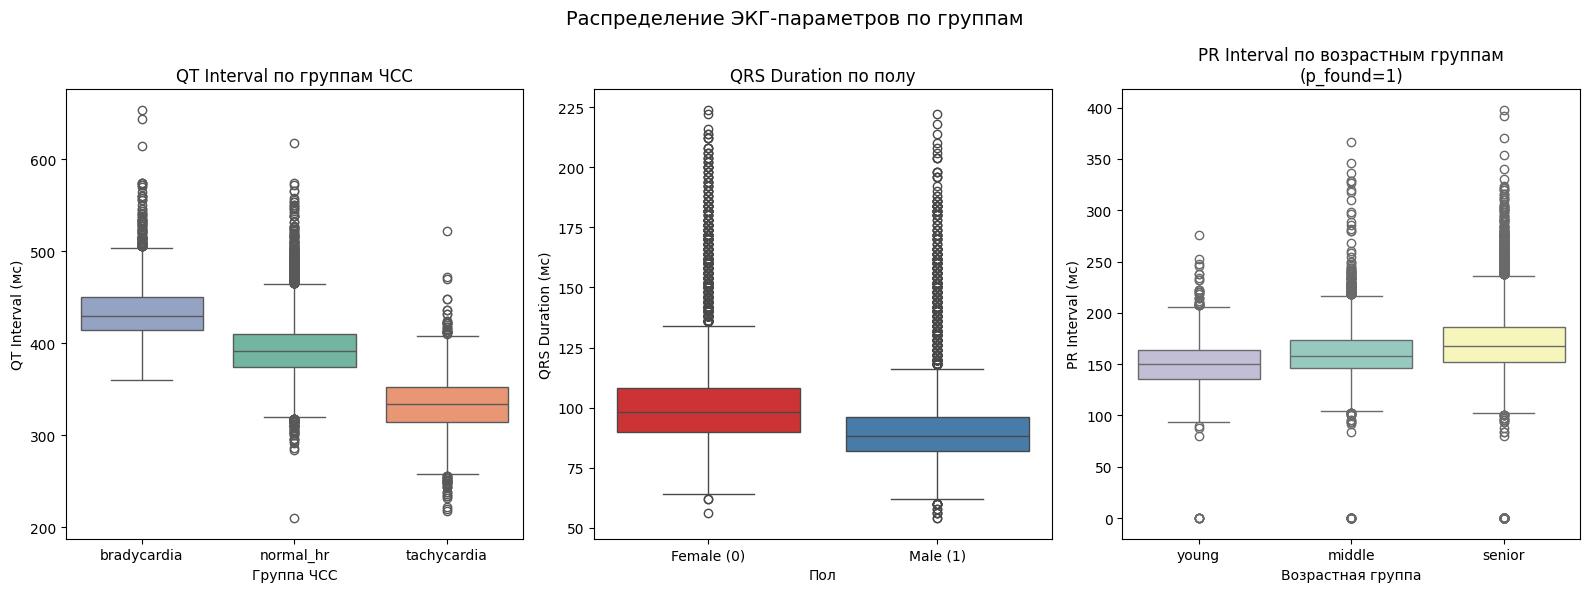

In [31]:
fig, axes = plt.subplots(1, 3, figsize = (16,6))
fig.suptitle('Распределение ЭКГ-параметров по группам', fontsize=14)
order = ['bradycardia', 'normal_hr', 'tachycardia']
sns.boxplot(data=cdata, x='heart_rate_group', y='qt_interval',order=order,ax=axes[0],palette='Set2',hue='heart_rate_group', legend=False)
axes[0].set_title('QT Interval по группам ЧСС')
axes[0].set_xlabel('Группа ЧСС')
axes[0].set_ylabel('QT Interval (мс)')

sns.boxplot(data=cdata, x='sex', y='qrs_duration', ax=axes[1], palette='Set1', hue='sex', legend=False)
axes[1].set_xticklabels(['Female (0)', 'Male (1)'])
axes[1].set_title('QRS Duration по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('QRS Duration (мс)')

pr_data=cdata[cdata['p_found'] == 1]
age_order = ['young', 'middle', 'senior']
sns.boxplot(data=pr_data, x='age_group', y='pr_interval', order=age_order, ax=axes[2], palette='Set3', hue='age_group', legend=False)
axes[2].set_title('PR Interval по возрастным группам\n(p_found=1)')
axes[2].set_xlabel('Возрастная группа')
axes[2].set_ylabel('PR Interval (мс)')
plt.tight_layout()
plt.show()

In [32]:
cdata.head()

,age,sex,strat_fold,filename_lr,scp_codes,heart_rate,rr_mean,qrs_count,pr_interval,qrs_duration,...,scp_STE_,scp_WPW,scp_INJIN,abnormal_flag,num_diagnoses,age_group,heart_rate_group,qtc_spread,axis_deviation,pr_missing
0,56.0,1,3,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",64.0,938.0,11.0,154.0,80.0,...,0.0,0.0,0.0,0,1,middle,normal_hr,4.0,normal,0
1,87.0,1,2,records100/21000/21803_lr,"{'CRBBB': 100.0, 'SARRH': 0.0}",75.0,802.0,12.0,144.0,120.0,...,0.0,0.0,0.0,1,1,senior,normal_hr,21.0,normal,0
2,87.0,1,2,records100/21000/21804_lr,"{'CRBBB': 100.0, 'AFIB': 0.0}",169.0,354.0,27.0,0.0,116.0,...,0.0,0.0,0.0,1,1,senior,tachycardia,84.0,normal,1
3,72.0,0,3,records100/21000/21805_lr,"{'ASMI': 100.0, 'ISCAL': 100.0, 'LAFB': 100.0,...",79.0,756.0,13.0,184.0,100.0,...,0.0,0.0,0.0,1,4,senior,normal_hr,22.0,left_deviation,0
4,85.0,0,5,records100/21000/21806_lr,"{'NDT': 100.0, 'SR': 0.0}",92.0,650.0,15.0,198.0,90.0,...,0.0,0.0,0.0,1,1,senior,normal_hr,28.0,normal,0


In [33]:
columns = [
    'heart_rate',
    'pr_interval',
    'qrs_duration',
    'qt_interval'
]

<Axes: >

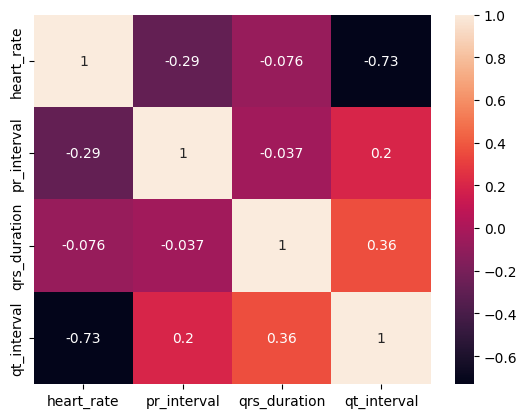

In [34]:
sns.heatmap(cdata[columns].corr(), annot=True)

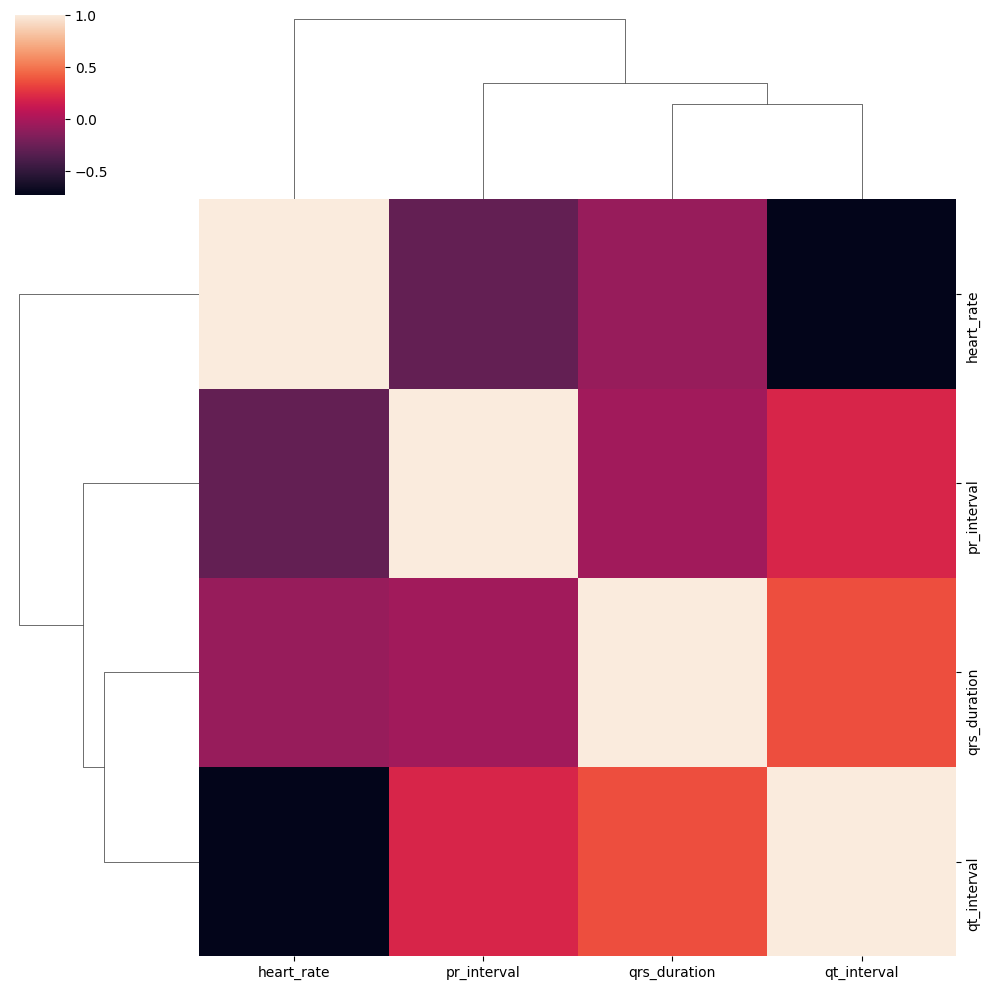

In [35]:
sns.clustermap(cdata[columns].corr())

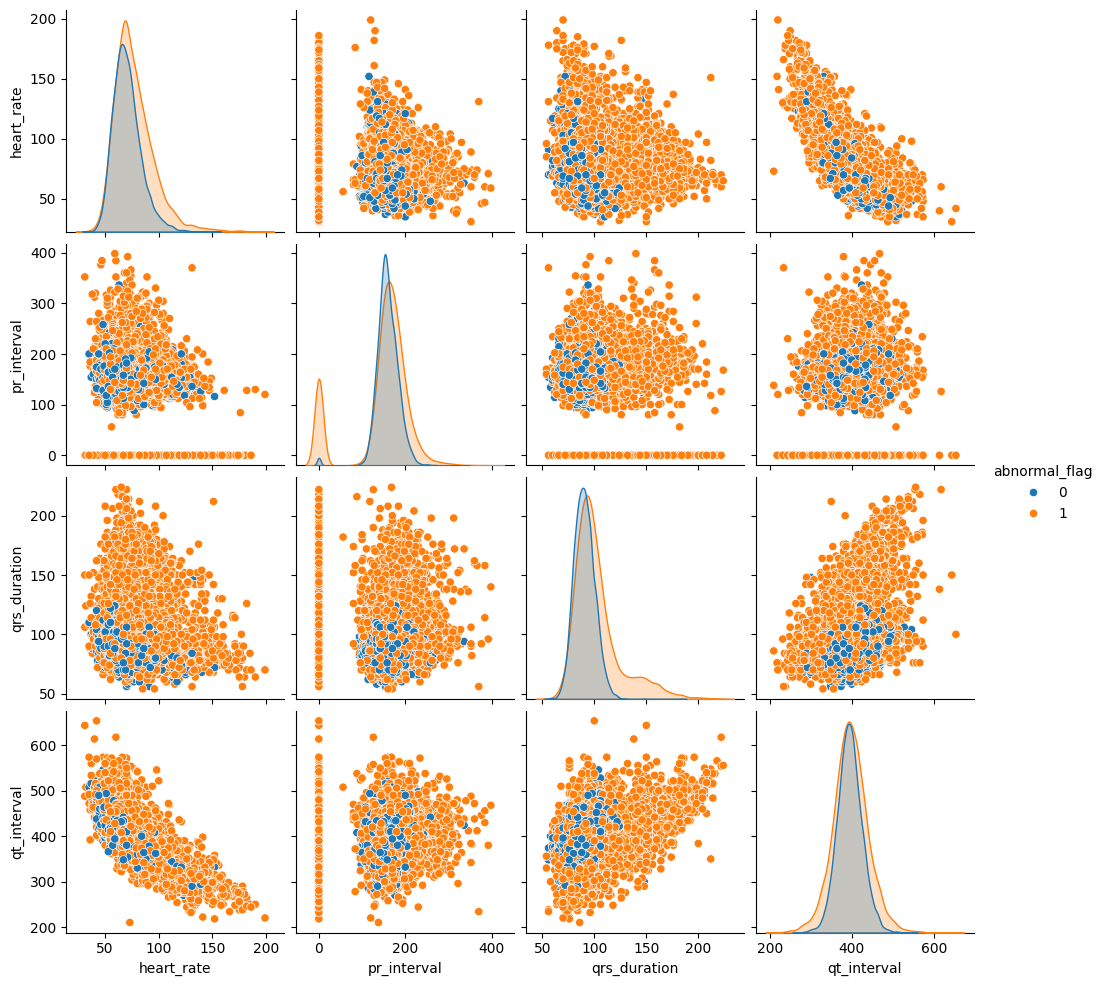

In [36]:
sns.pairplot(cdata[columns + ['abnormal_flag']], hue='abnormal_flag')

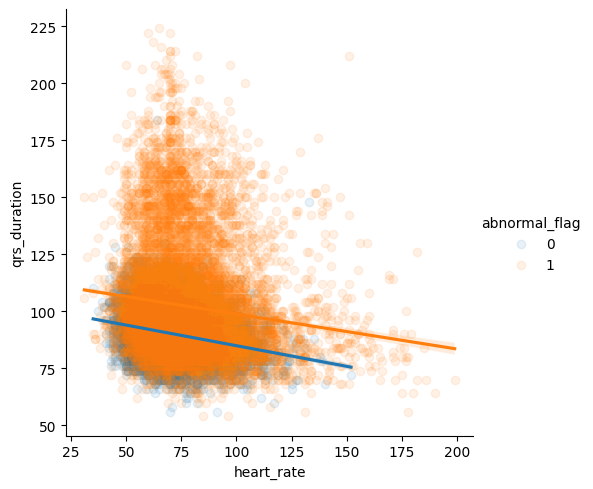

In [37]:
sns.lmplot(cdata, x='heart_rate', y='qrs_duration', scatter_kws={"alpha": 0.1}, hue='abnormal_flag')

In [49]:
import plotly.express as px

In [ ]:
codes = data["scp_codes"].apply(ast.literal_eval)
codes = codes.apply(lambda x : list(x.keys())).sum()

['NORM',
 'LVOLT',
 'SR',
 'CRBBB',
 'SARRH',
 'CRBBB',
 'AFIB',
 'ASMI',
 'ISCAL',
 'LAFB',
 'ANEUR',
 'ABQRS',
 'SR',
 'NDT',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'ABQRS',
 'SR',
 'NORM',
 'SR',
 'IMI',
 'ABQRS',
 'SR',
 'CRBBB',
 'LAFB',
 '1AVB',
 'ABQRS',
 'SVARR',
 'NORM',
 'SBRAD',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'IMI',
 'ABQRS',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'IMI',
 'AMI',
 'LAFB',
 '1AVB',
 'ABQRS',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SARRH',
 'NORM',
 'SBRAD',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SARRH',
 'NORM',
 'SR',
 'AFLT',
 'ABQRS',
 'AFIB',
 'AFLT',
 'NORM',
 'SR',
 'AFLT',
 'ABQRS',
 'NORM',
 'SR',
 'NDT',
 'SR',
 'AFLT',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NST_',
 'DIG',
 'SR',
 'NORM',
 'SR',
 'NST_',
 'DIG',
 'SR',
 'NORM',
 'SR',
 'LVH',
 'SR',
 'NORM',
 'SR',
 'LPFB',
 'SR',
 'NORM',
 'SR',
 'AFLT',
 'NORM',
 'SR',
 'NORM',
 'SR',
 'NORM',
 'SARRH',
 'NORM',
 'SR',
 'IMI',
 'L

In [51]:
px.pie(names=codes)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
              'hovertemplate': 'label=%{label}<extra></extra>',
              'labels': array(['NORM', 'LVOLT', 'SR', ..., 'CRBBB', 'RVH', 'SR'],
                              shape=(61007,), dtype=object),
              'legendgroup': '',
              'name': '',
              'showlegend': True,
              'type': 'pie'}],
    'layout': {'legend': {'tracegroupgap': 0}, 'margin': {'t': 60}, 'template': '...'}
})